# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- **Nama:** Ahmad Nurus Sholihin
- **Email:** ansstatistika295@gmail.com
- **ID Dicoding:** ahmad_nurus_sholihin

## Persiapan

### Menyiapkan library yang dibutuhkan

In [ ]:
# Library utama untuk analisis data dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Utility untuk menampilkan tabel dengan format notebook
from IPython.display import display
# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score


### Menyiapkan data yang akan diguankan

In [34]:
# link dataset 
url = "https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/main/employee/employee_data.csv"
df = pd.read_csv(url)
# Melihat 5 data teratas
print(df.head())

   EmployeeId  Age  Attrition     BusinessTravel  DailyRate  \
0           1   38        NaN  Travel_Frequently       1444   
1           2   37        1.0      Travel_Rarely       1141   
2           3   51        1.0      Travel_Rarely       1323   
3           4   42        0.0  Travel_Frequently        555   
4           5   40        NaN      Travel_Rarely       1194   

               Department  DistanceFromHome  Education EducationField  \
0         Human Resources                 1          4          Other   
1  Research & Development                11          2        Medical   
2  Research & Development                 4          4  Life Sciences   
3                   Sales                26          3      Marketing   
4  Research & Development                 2          4        Medical   

   EmployeeCount  ...  RelationshipSatisfaction StandardHours  \
0              1  ...                         2            80   
1              1  ...                         1     

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   EmployeeId                1470 non-null   int64  
 1   Age                       1470 non-null   int64  
 2   Attrition                 1058 non-null   float64
 3   BusinessTravel            1470 non-null   object 
 4   DailyRate                 1470 non-null   int64  
 5   Department                1470 non-null   object 
 6   DistanceFromHome          1470 non-null   int64  
 7   Education                 1470 non-null   int64  
 8   EducationField            1470 non-null   object 
 9   EmployeeCount             1470 non-null   int64  
 10  EnvironmentSatisfaction   1470 non-null   int64  
 11  Gender                    1470 non-null   object 
 12  HourlyRate                1470 non-null   int64  
 13  JobInvolvement            1470 non-null   int64  
 14  JobLevel

In [36]:
# Daftar kolom angka yang secara logika adalah kategori / label
kolom_kategori = [
    'EmployeeId', 'Attrition', 'Education', 'EnvironmentSatisfaction', 
    'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'PerformanceRating', 
    'RelationshipSatisfaction', 'StockOptionLevel', 'WorkLifeBalance'
]

# Mengubah tipe datanya menjadi object (string)
df[kolom_kategori] = df[kolom_kategori].astype('object')

# Mengecek kembali hasilnya
print("--- Tipe Data Setelah Diperbaiki ---")
print(df[kolom_kategori].dtypes)

--- Tipe Data Setelah Diperbaiki ---
EmployeeId                  object
Attrition                   object
Education                   object
EnvironmentSatisfaction     object
JobInvolvement              object
JobLevel                    object
JobSatisfaction             object
PerformanceRating           object
RelationshipSatisfaction    object
StockOptionLevel            object
WorkLifeBalance             object
dtype: object


## Data Understanding

Jumlah baris dan kolom: (1470, 35)

Tipe data tiap kolom:
EmployeeId                  object
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                   object
EducationField              object
EmployeeCount                int64
EnvironmentSatisfaction     object
Gender                      object
HourlyRate                   int64
JobInvolvement              object
JobLevel                    object
JobRole                     object
JobSatisfaction             object
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating           object
RelationshipSatisfaction    object
StandardHours                int

,Age,DailyRate,DistanceFromHome,EmployeeCount,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,PercentSalaryHike,StandardHours,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,1.0,65.891156,6502.931293,14313.103401,2.693197,15.209524,80.0,11.279592,2.799320,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,0.0,20.329428,4707.956783,7117.786044,2.498009,3.659938,0.0,7.780782,1.289271,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.0,30.000000,1009.000000,2094.000000,0.000000,11.000000,80.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,1.0,48.000000,2911.000000,8047.000000,1.000000,12.000000,80.0,6.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,1.0,66.000000,4919.000000,14235.500000,2.000000,14.000000,80.0,10.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,1.0,83.750000,8379.000000,20461.500000,4.000000,18.000000,80.0,15.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,1.0,100.000000,19999.000000,26999.000000,9.000000,25.000000,80.0,40.000000,6.000000,40.000000,18.000000,15.000000,17.000000



Statistik kategorikal:


,EmployeeId,Attrition,BusinessTravel,Department,Education,EducationField,EnvironmentSatisfaction,Gender,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,Over18,OverTime,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,WorkLifeBalance
count,1470,1058.0,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,1470,2.0,3,3,5,6,4,2,4,5,9,4,3,1,2,2,4,4,4
top,1470,0.0,Travel_Rarely,Research & Development,3,Life Sciences,3,Male,3,1,Sales Executive,4,Married,Y,No,3,3,0,3
freq,1,879.0,1043,961,572,606,453,882,868,543,326,459,673,1470,1054,1244,459,631,893



Jumlah missing value per kolom:


Attrition    412
dtype: int64


Distribusi target 'Attrition':


Attrition
0.0    879
1.0    179
Name: count, dtype: int64

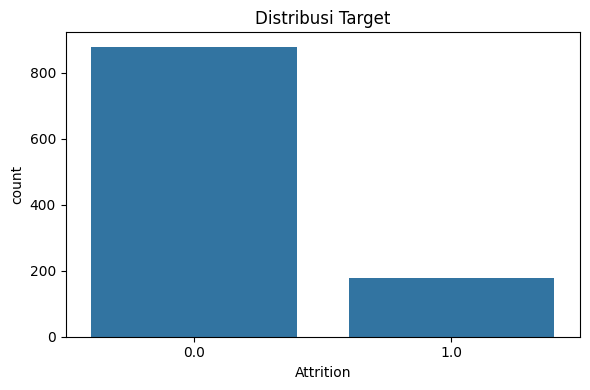

In [37]:
# Menampilkan struktur data
print("Jumlah baris dan kolom:", df.shape)
print("\nTipe data tiap kolom:")
print(df.dtypes)

# Statistik deskriptif
print("\nStatistik numerik:")
display(df.describe())

print("\nStatistik kategorikal:")
display(df.describe(include="object"))

# Cek missing value
missing_values = df.isna().sum().sort_values(ascending=False)
print("\nJumlah missing value per kolom:")
display(missing_values[missing_values > 0])

# Cek distribusi target (jika ada kolom Attrition)
target_candidates = ["Attrition", "attrition"]
target_col = next((c for c in target_candidates if c in df.columns), None)

if target_col is not None:
    print(f"\nDistribusi target '{target_col}':")
    display(df[target_col].value_counts())

    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=target_col)
    plt.title("Distribusi Target")
    plt.tight_layout()
    plt.show()
else:
    print("Kolom target Attrition tidak ditemukan. Pastikan nama kolom target sesuai dataset.")

## Data Preparation / Preprocessing

In [38]:
# Salin data agar data asli tetap aman
df_prep = df.copy()

# Hapus duplikasi jika ada
before_rows = df_prep.shape[0]
df_prep = df_prep.drop_duplicates()
after_rows = df_prep.shape[0]
print(f"Jumlah baris sebelum drop duplicate: {before_rows}")
print(f"Jumlah baris sesudah drop duplicate: {after_rows}")

# Tentukan kolom target
target_candidates = ["Attrition", "attrition"]
target_col = next((c for c in target_candidates if c in df_prep.columns), None)

if target_col is None:
    raise ValueError("Kolom target tidak ditemukan. Gunakan nama kolom target yang benar.")

# Hapus baris dengan target kosong
before_target_drop = df_prep.shape[0]
df_prep = df_prep.dropna(subset=[target_col]).copy()
after_target_drop = df_prep.shape[0]
print(f"Jumlah baris sebelum drop target kosong: {before_target_drop}")
print(f"Jumlah baris sesudah drop target kosong: {after_target_drop}")

# Pisahkan fitur dan target
X = df_prep.drop(columns=[target_col])
y = df_prep[target_col].copy()

# Ubah target menjadi biner secara robust untuk tipe numerik/object
y_numeric = pd.to_numeric(y, errors="coerce")
if y_numeric.notna().all():
    y = y_numeric.astype(int)
else:
    y_str = y.astype(str).str.strip().str.lower()
    y = y_str.map({
        "yes": 1, "no": 0,
        "1": 1, "0": 0,
        "1.0": 1, "0.0": 0,
        "true": 1, "false": 0
    })

    if y.isna().any():
        # fallback jika label target tidak sesuai mapping di atas
        y = pd.Series(pd.factorize(df_prep[target_col])[0], index=df_prep.index)

# Pastikan target tanpa missing value
if pd.Series(y).isna().any():
    raise ValueError("Target masih mengandung missing value setelah preprocessing.")

# Tangani missing value fitur
num_cols = X.select_dtypes(include=[np.number]).columns
cat_cols = X.select_dtypes(exclude=[np.number]).columns

for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    mode_value = X[col].mode()[0]
    X[col] = X[col].astype("string").fillna(mode_value)

# One-hot encoding fitur kategorikal
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split train-test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Ukuran data train:", X_train.shape)
print("Ukuran data test:", X_test.shape)

Jumlah baris sebelum drop duplicate: 1470
Jumlah baris sesudah drop duplicate: 1470
Jumlah baris sebelum drop target kosong: 1470
Jumlah baris sesudah drop target kosong: 1058
Ukuran data train: (846, 1121)
Ukuran data test: (212, 1121)


## Modeling

In [ ]:
# Inisialisasi model
models = {
    "Logistic Regression": Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            ("classifier", LogisticRegression(
                max_iter=3000,
                class_weight="balanced",
                solver="lbfgs",
                random_state=42
            ))
        ]
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight="balanced"
    )
}

# Training dan evaluasi awal
model_results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    result = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
    }
    model_results.append(result)
    trained_models[model_name] = model

results_df = pd.DataFrame(model_results).sort_values(by="f1", ascending=False)
display(results_df)

best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]
print(f"Model terbaik (berdasarkan F1): {best_model_name}")

,model,accuracy,precision,recall,f1
1,Random Forest,0.844340,1.0,0.083333,0.153846
0,Logistic Regression,0.839623,1.0,0.055556,0.105263


Model terbaik (berdasarkan F1): Random Forest


## Evaluation

Classification Report:
              precision    recall  f1-score   support

           0     0.8421    1.0000    0.9143       176
           1     1.0000    0.0833    0.1538        36

    accuracy                         0.8443       212
   macro avg     0.9211    0.5417    0.5341       212
weighted avg     0.8689    0.8443    0.7852       212



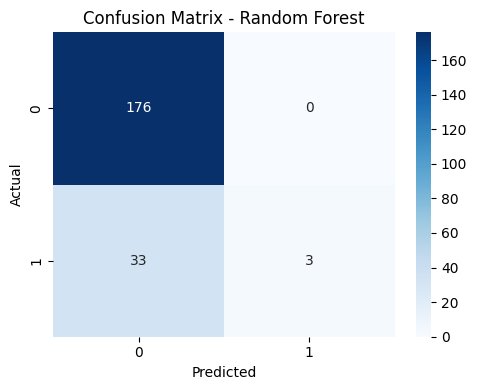

ROC-AUC Score: 0.8199


In [ ]:
# Prediksi model terbaik
y_pred_best = best_model.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred_best, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# ROC-AUC jika model punya predict_proba
if hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)
    print(f"ROC-AUC Score: {roc_auc:.4f}")
else:
    print("Model tidak mendukung predict_proba, ROC-AUC tidak dihitung.")